# BSAN391 - The Okto Masks Linear Program - V2

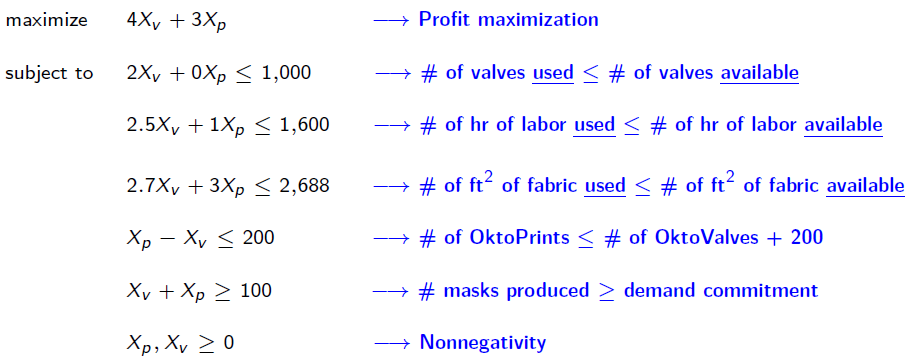

In [1]:
from gurobipy import *

In [2]:
# Resources capacity
resources, capacity = multidict({"Valves": 1000, "Labor": 1600, "Fabric": 2688})

# Resorces consumption by product
consumption = {("V","Valves"): 2,   ("P","Valves"): 0, 
               ("V","Labor"): 2.5,  ("P","Labor"): 1,
               ("V","Fabric"): 2.7, ("P","Fabric"): 3}

#Products data
products, profit = multidict({"V": 4, "P": 3})


# Let's take a look at what we've defined here
print("Resources:",resources) # a list
print("Capacities:",capacity) # a dictionary
print("Products:", products) # a list
print("Unit profits:", profit)

Resources: ['Valves', 'Labor', 'Fabric']
Capacities: {'Valves': 1000, 'Labor': 1600, 'Fabric': 2688}
Products: ['V', 'P']
Unit profits: {'V': 4, 'P': 3}


In [3]:
# Create new model
oktomasks = Model("OktoMasks")

Academic license - for non-commercial use only - expires 2023-08-13
Using license file C:\Users\luisj\gurobi.lic


In [4]:
# Create decision variables - Default values are applied: decision variables are continuous, nonnegative and with no upper bound
production = oktomasks.addVars(products, name="X")
print(production)

{'V': <gurobi.Var *Awaiting Model Update*>, 'P': <gurobi.Var *Awaiting Model Update*>}


In [5]:
# Define objective function
#oktomasks.setObjective(production.prod(profit), GRB.MAXIMIZE) # an equivalent definition
oktomasks.setObjective(quicksum(production[i]*profit[i] for i in products), GRB.MAXIMIZE)

In [6]:
# Add constraints - Adds constraints to the model object (linear expression as LHS, sense of constraint, RHS value, and name)
resources = oktomasks.addConstrs(((sum(consumption[p,r]*production[p] for p in products) <= capacity[r]) for r in resources), name="R")
difference = oktomasks.addConstr(production["P"] - production["V"] <= 200, "OktoPrints - OktoValves")
commitment = oktomasks.addConstr(production["P"] + production["V"] >= 100, "Demand commitment")

In [7]:
# Run optimization engine
oktomasks.optimize()
oktomasks.write("oktomasks2.lp")

Gurobi Optimizer version 9.1.2 build v9.1.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 5 rows, 2 columns and 9 nonzeros
Model fingerprint: 0x7a6efd3d
Coefficient statistics:
  Matrix range     [1e+00, 3e+00]
  Objective range  [3e+00, 4e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+02, 3e+03]
Presolve removed 1 rows and 0 columns
Presolve time: 0.01s
Presolved: 4 rows, 2 columns, 8 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    4.8000000e+03   7.068247e+02   0.000000e+00      0s
       2    3.2600000e+03   0.000000e+00   0.000000e+00      0s

Solved in 2 iterations and 0.01 seconds
Optimal objective  3.260000000e+03


In [8]:
# Display optimal production plan
for v in oktomasks.getVars():
    print(v.varName, v.x)
    
print("Optimal total profit:", "$"+str(oktomasks.objVal))

X[V] 440.0
X[P] 500.0
Optimal total profit: $3260.0


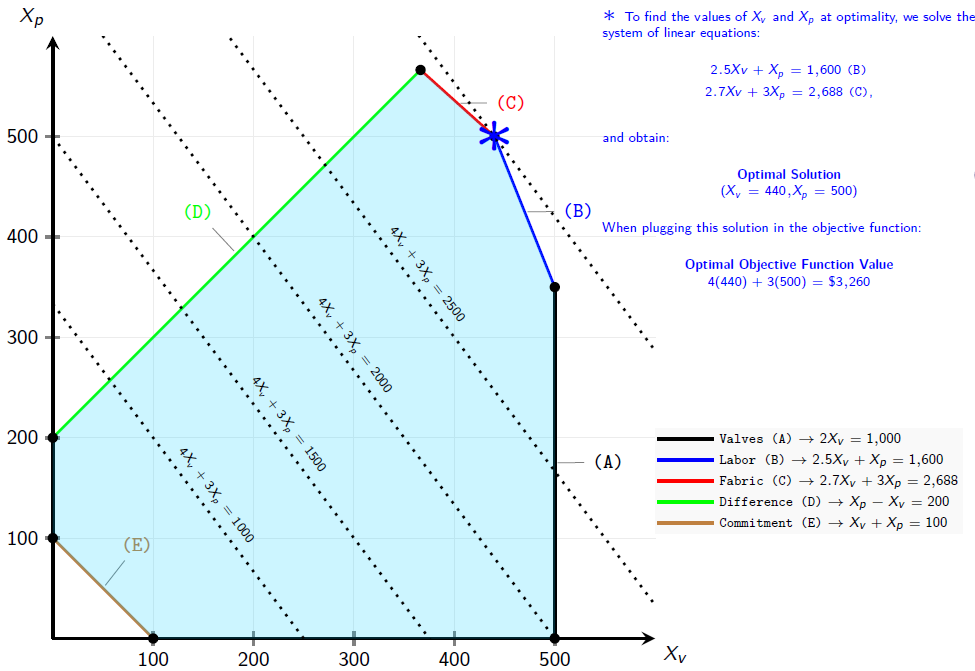